# Para llegar a su sitio en el cerebro, una neurona se rompe el ADN

Recién nacida, una neurona del cerebelo tiene que apretujarse por pasadizos más estrechos que su propio núcleo. Y en cada apretón, se le parten las dos cadenas del ADN.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** Zhang et al. (2026). *Confined migration induces non-lethal DNA damage in developing neurons.* Nature.
**DOI:** [10.1038/s41586-026-10648-8](https://doi.org/10.1038/s41586-026-10648-8)
**Video:** [Ver en YouTube](https://youtube.com/shorts/Xm7KcWfZ_dE) · [![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-07-02-neuronas-migracion-dano-adn/notebook.ipynb)

## El viaje más peligroso de tu cerebro lo hiciste antes de nacer

En el cerebelo de un ratón recién nacido, las neuronas granulares nacen en la superficie y tienen que viajar hacia adentro, colándose entre células apretadas hasta llegar a su capa final. Es una mudanza masiva: millones de neuronas migrando en pocos días.

El daño al ADN casi siempre lo asociamos con algo malo —cáncer, envejecimiento, radiación—. Lo raro de este paper es que encontró ese mismo daño como parte **normal** del desarrollo: aparece justo cuando la neurona se aprieta para migrar, y desaparece cuando llega a casa. Vamos a abrir sus datos y verlo.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
ANCHO_CORREDOR_FOCO = 3      # µm — el corredor estrecho que más daño causa
REPARACION_MEDIANA = 82      # min — vida media típica de un foco de reparación
COLOR_DATOS = '#2563EB'      # azul CaM
COLOR_ALERTA = '#DC2626'     # rojo (daño / mutante)
COLOR_DESTINO = '#059669'    # emerald (capa destino)
COLOR_REFERENCIA = '#D97706' # amber (umbral / mediana)
FUENTE = 'Fuente: Zhang et al. (2026), Nature | Datos: Source Data Fig. 1 y Fig. 5'

import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local → fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)
os.makedirs('figuras', exist_ok=True)

# Carga de los 4 datasets (derivados de los Source Data del paper)
gamma = pd.read_csv('datos/gamma_h2ax_desarrollo.csv')   # daño por estadio y capa
corredor = pd.read_csv('datos/corredor_dano.csv')        # daño por ancho de corredor
reparacion = pd.read_csv('datos/reparacion_53bp1_min.csv')  # vida media de reparación
andar = pd.read_csv('datos/andar_lig4.csv')              # ancho del andar Control vs mutante

print(f'γ-H2AX (daño):   {len(gamma)} mediciones, {gamma.dia_postnatal.nunique()} estadios (P4→P30)')
print(f'Corredores:      {len(corredor)} mediciones, anchos {[int(w) for w in sorted(corredor.ancho_corredor_um.unique())]} µm')
print(f'Reparación:      {len(reparacion)} focos 53BP1 cronometrados')
print(f'Andar:           {len(andar)} huellas ({andar.genotipo.value_counts().to_dict()})')

γ-H2AX (daño):   110 mediciones, 6 estadios (P4→P30)
Corredores:      29 mediciones, anchos [2, 3, 4, 5] µm
Reparación:      66 focos 53BP1 cronometrados
Andar:           143 huellas ({'Control': 74, 'Lig4 KO (ND1-Cre)': 69})


## Aquí está.

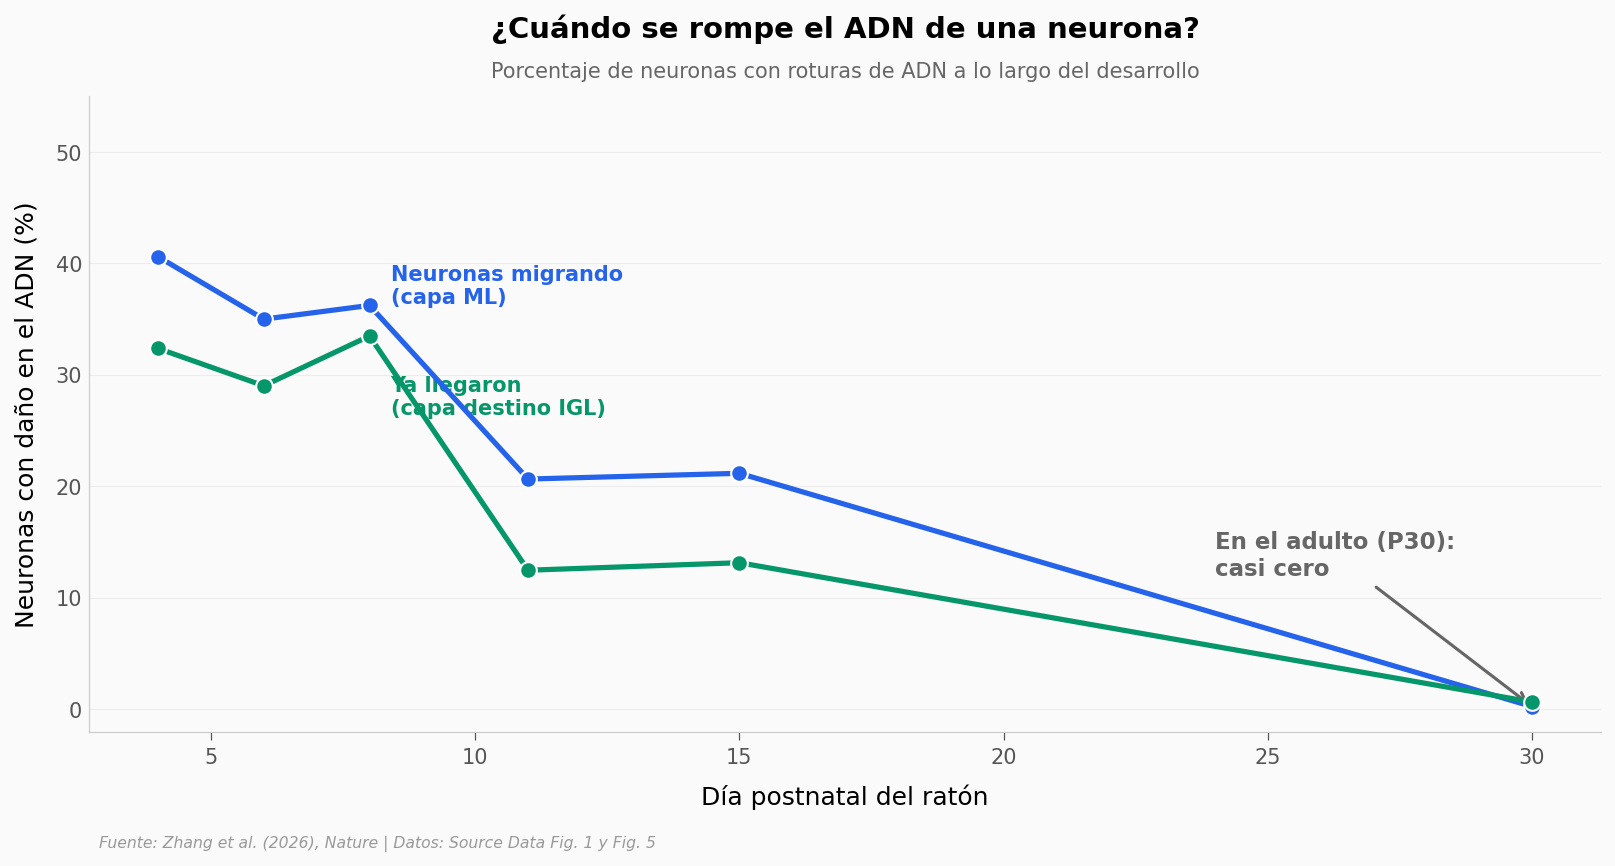

Pico durante la migración (ML, P4): 40.6%
En el cerebro adulto (ML, P30):     0.2%


In [2]:
# El marcador γ-H2AX señala roturas de doble cadena del ADN.
# ML = capa donde las neuronas MIGRAN | IGL = capa DESTINO (donde ya llegaron)
ml = gamma[gamma.capa == 'ML'].groupby('dia_postnatal').gamma_h2ax_pct.mean()
igl = gamma[gamma.capa == 'IGL'].groupby('dia_postnatal').gamma_h2ax_pct.mean()

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.plot(ml.index, ml.values, '-o', color=COLOR_DATOS, linewidth=2.5,
        markersize=8, markeredgecolor='white', markeredgewidth=1, zorder=5)
ax.plot(igl.index, igl.values, '-o', color=COLOR_DESTINO, linewidth=2.5,
        markersize=8, markeredgecolor='white', markeredgewidth=1, zorder=5)

# Inline labels (sin legend box)
ax.text(8.4, 38, 'Neuronas migrando\n(capa ML)', fontsize=10,
        color=COLOR_DATOS, fontweight='bold', va='center')
ax.text(8.4, 28, 'Ya llegaron\n(capa destino IGL)', fontsize=10,
        color=COLOR_DESTINO, fontweight='bold', va='center')

# Anotar la caída al adulto
ax.annotate('En el adulto (P30):\ncasi cero',
            xy=(30, ml.loc[30]), xytext=(24, 12),
            fontsize=11, fontweight='bold', color='#666666',
            arrowprops=dict(arrowstyle='->', color='#666666', lw=1.5))

ax.set_title('¿Cuándo se rompe el ADN de una neurona?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Porcentaje de neuronas con roturas de ADN a lo largo del desarrollo',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Día postnatal del ratón')
ax.set_ylabel('Neuronas con daño en el ADN (%)')
ax.set_ylim(-2, 55)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dano_desarrollo.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'Pico durante la migración (ML, P4): {ml.loc[4]:.1f}%')
print(f'En el cerebro adulto (ML, P30):     {ml.loc[30]:.1f}%')

Mientras las neuronas migran (días 4 a 8), **4 de cada 10** llevan el ADN roto: un 41% en la capa de migración. Es muchísimo daño para una célula sana.

Y luego, la parte tranquilizadora: para cuando el cerebro es adulto (día 30), el daño baja a **0,2%** —prácticamente desaparece—. No es una enfermedad que se acumula; es una marca del viaje que se borra al llegar.

Un detalle de método que importa: aquí nadie provocó el daño. Los investigadores midieron neuronas en distintos momentos del desarrollo y las contaron. Por eso decimos que el daño *acompaña* a la migración —no que la migración lo *cause*—. Esa distinción la resolverán en la siguiente gráfica.

## ¿Y si el culpable es el apretón?

La sospecha era mecánica: el núcleo de la neurona se deforma al pasar por huecos estrechos, y esa presión parte el ADN. Para probarlo —ahora sí, un experimento— hicieron migrar neuronas por corredores fabricados de distintos anchos, de 2 a 5 micrómetros, y contaron cuántas terminaban con daño.

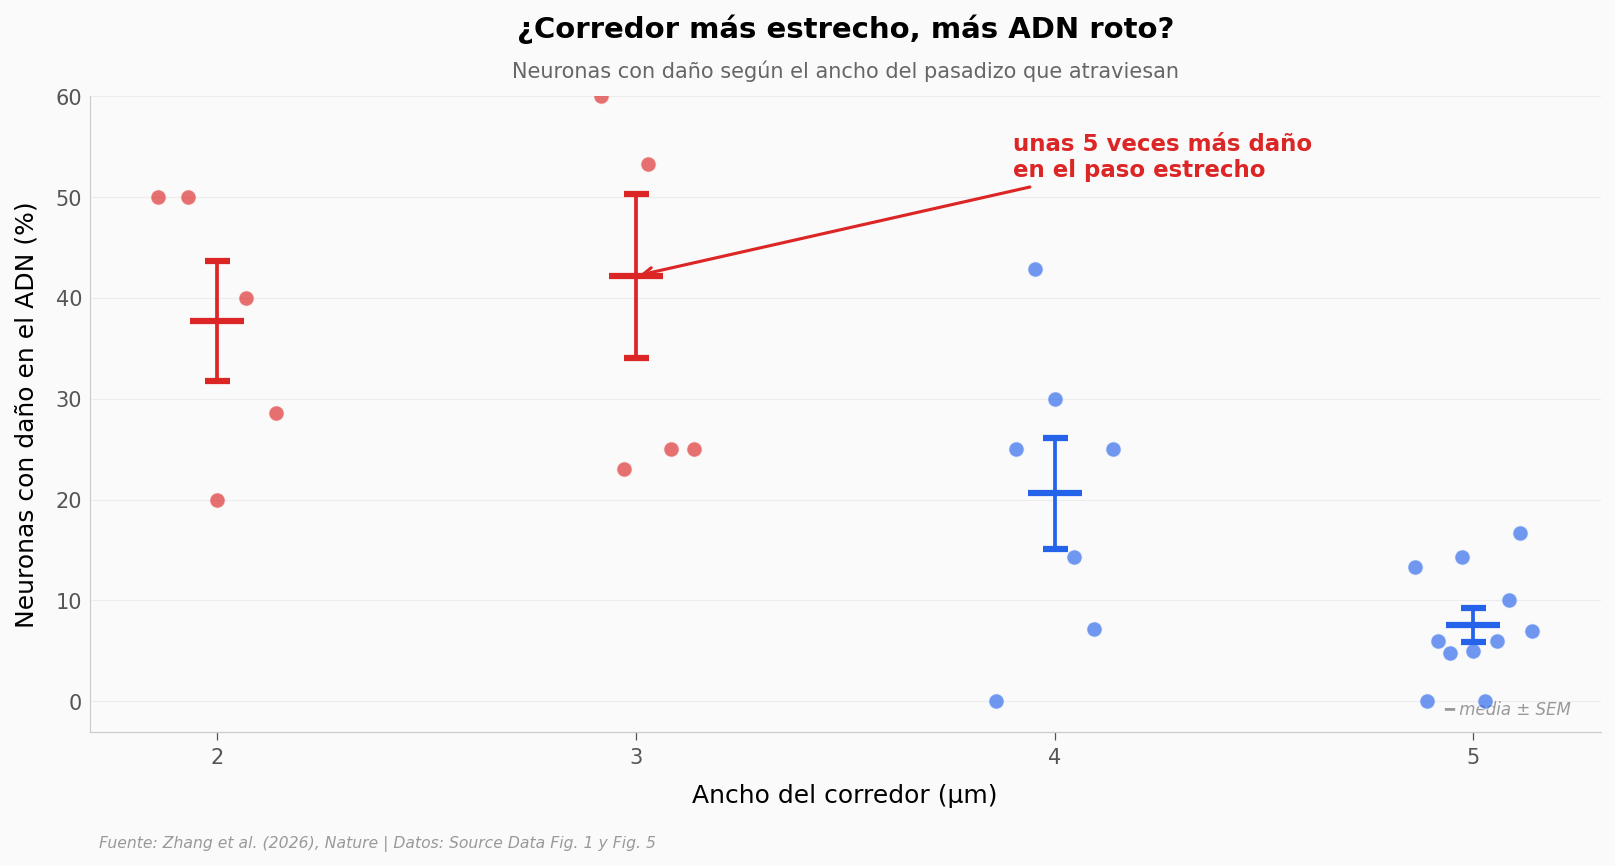

Corredor de 3 µm: 42% con daño  |  corredor de 5 µm: 8% con daño
Correlación ancho vs daño: Spearman ρ = -0.76 (p = 1.7e-06) — a más estrecho, más daño


In [3]:
# Experimento de corredores: cada punto es una medición; la barra es la media por ancho.
np.random.seed(42)  # jitter reproducible
anchos = sorted(corredor.ancho_corredor_um.unique())
fig, ax = plt.subplots(figsize=(13, 5.5))

for i, w in enumerate(anchos):
    vals = corredor[corredor.ancho_corredor_um == w].pct_53bp1_positivo.values
    n = len(vals)
    x_strip = np.linspace(w - 0.14, w + 0.14, n)
    np.random.shuffle(x_strip)
    color = COLOR_ALERTA if w <= 3 else COLOR_DATOS
    ax.scatter(x_strip, vals, color=color, s=55, alpha=0.65,
               edgecolors='white', linewidths=0.6, zorder=5)
    m = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    ax.errorbar(w, m, yerr=sem, fmt='_', color=color, markersize=26,
                markeredgewidth=3, capsize=6, capthick=1.5, zorder=6)

est = corredor[corredor.ancho_corredor_um == 3].pct_53bp1_positivo.mean()
anc = corredor[corredor.ancho_corredor_um == 5].pct_53bp1_positivo.mean()
ax.annotate('unas 5 veces más daño\nen el paso estrecho',
            xy=(3, est), xytext=(3.9, 52),
            fontsize=11, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.5))

ax.set_title('¿Corredor más estrecho, más ADN roto?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Neuronas con daño según el ancho del pasadizo que atraviesan',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Ancho del corredor (µm)')
ax.set_ylabel('Neuronas con daño en el ADN (%)')
ax.set_xticks(anchos)
ax.set_ylim(-3, 60)
ax.text(0.98, 0.02, '━ media ± SEM', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/corredor.png', dpi=200, bbox_inches='tight')
plt.show()

rho, p = stats.spearmanr(corredor.ancho_corredor_um, corredor.pct_53bp1_positivo)
print(f'Corredor de 3 µm: {est:.0f}% con daño  |  corredor de 5 µm: {anc:.0f}% con daño')
print(f'Correlación ancho vs daño: Spearman ρ = {rho:.2f} (p = {p:.1e}) — a más estrecho, más daño')

## La neurona no se muere: se remienda sobre la marcha

Aquí está lo elegante. Romper el ADN suena letal, pero estas neuronas no mueren. Encienden su maquinaria de reparación (unas marcas llamadas focos 53BP1), arreglan el corte y siguen migrando. Los investigadores cronometraron cuánto dura encendido cada foco: es la duración de una reparación.

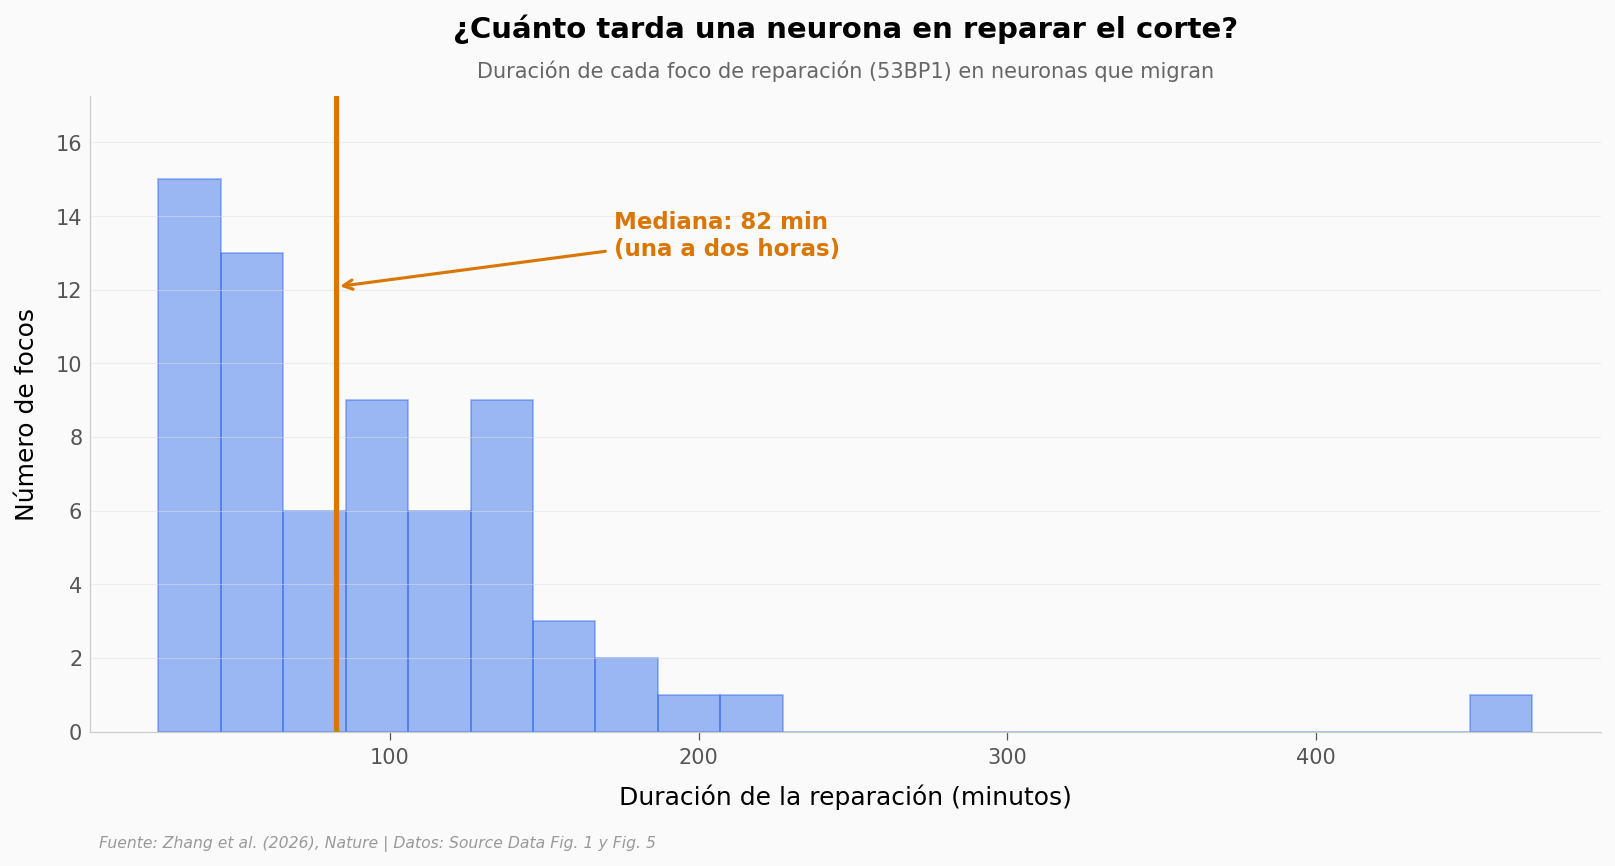

n = 66 focos cronometrados
Mediana: 82 min | IQR: 51–129 min | rango: 25–470 min
La cola larga (algunos tardan horas) hace que la mediana describa mejor el caso típico que el promedio.


In [4]:
r = reparacion.vida_media_53bp1_min.values
mediana = np.median(r)

fig, ax = plt.subplots(figsize=(13, 5.5))
n_bins, bins, _ = ax.hist(r, bins=22, color=COLOR_DATOS, alpha=0.45,
                          edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n_bins.max() * 1.15
ax.set_ylim(0, y_max)
ax.axvline(mediana, color=COLOR_REFERENCIA, linewidth=2.5)
ax.annotate(f'Mediana: {mediana:.0f} min\n(una a dos horas)',
            xy=(mediana, y_max * 0.7), xytext=(mediana + 90, y_max * 0.75),
            fontsize=11, fontweight='bold', color=COLOR_REFERENCIA,
            arrowprops=dict(arrowstyle='->', color=COLOR_REFERENCIA, lw=1.5))

ax.set_title('¿Cuánto tarda una neurona en reparar el corte?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Duración de cada foco de reparación (53BP1) en neuronas que migran',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Duración de la reparación (minutos)')
ax.set_ylabel('Número de focos')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/reparacion.png', dpi=200, bbox_inches='tight')
plt.show()

print(f'n = {len(r)} focos cronometrados')
print(f'Mediana: {mediana:.0f} min | IQR: {np.percentile(r,25):.0f}–{np.percentile(r,75):.0f} min | rango: {r.min():.0f}–{r.max():.0f} min')
print('La cola larga (algunos tardan horas) hace que la mediana describa mejor el caso típico que el promedio.')

## ¿Y si la reparación falla?

Última pregunta, la que le da sentido a todo. Si el daño es normal *porque* la neurona lo repara, ¿qué pasa si le quitamos la herramienta de reparar? Los investigadores apagaron un gen clave (la Ligasa IV, que sella los cortes) justo al inicio de la migración, y luego miraron algo sencillo: cómo caminan esos ratones de adultos.

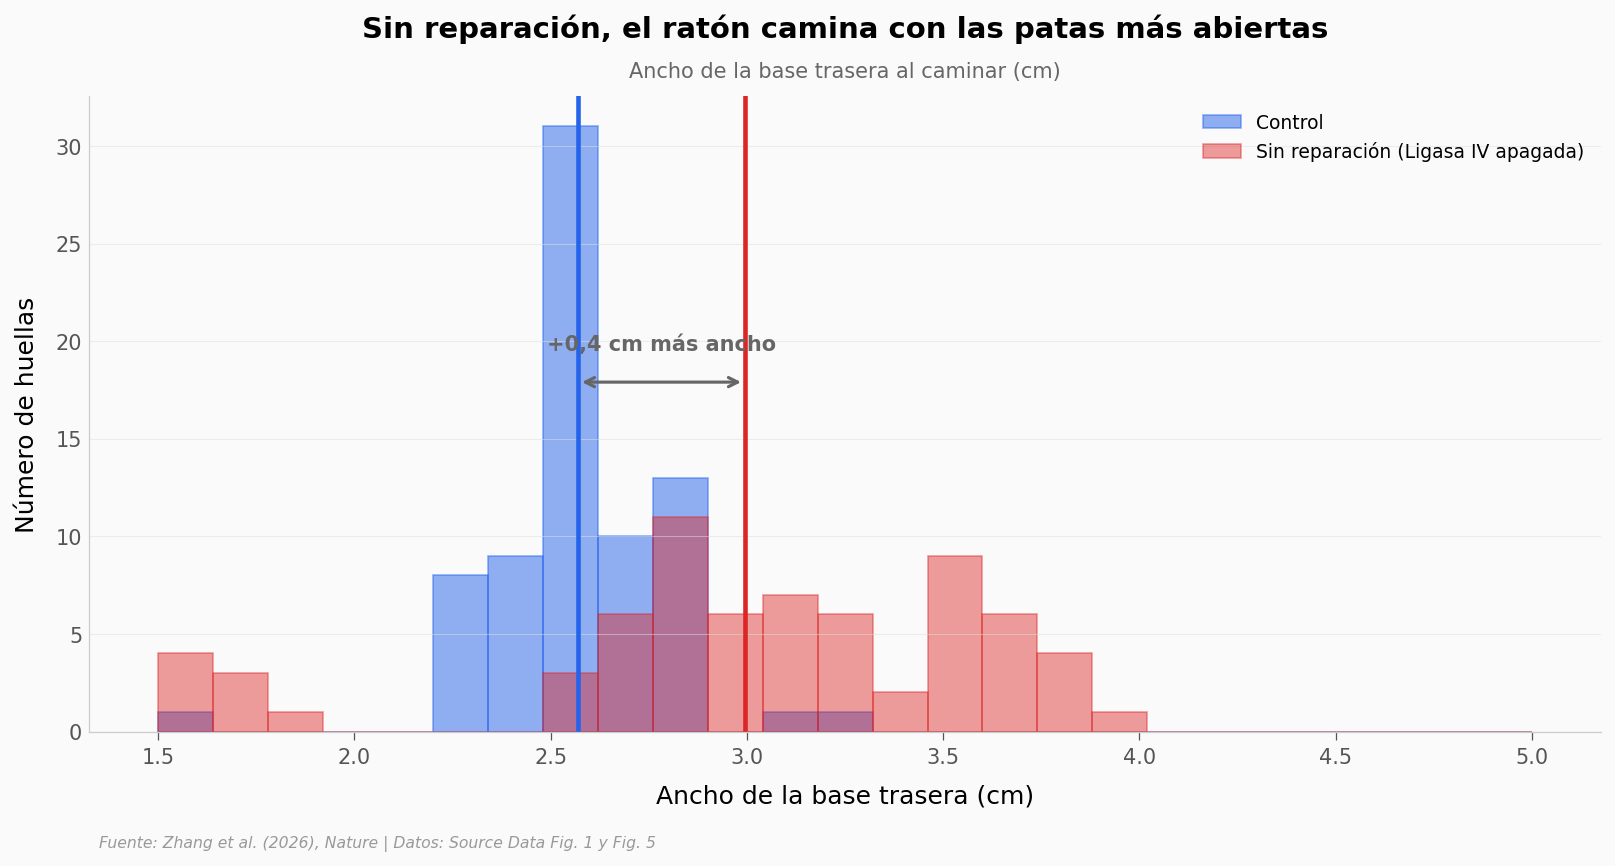

Control: 2.57 cm (n=74)  |  Sin reparación: 3.00 cm (n=69)
Diferencia: +0.43 cm (+17%)
Mann-Whitney U: p = 5.0e-11 (distribuciones no normales → test no paramétrico)
Nota: varias huellas por ratón sin identificador (pseudorréplicas) → leer como "andar más amplio y variable".


In [5]:
ctrl = andar[andar.genotipo == 'Control'].ancho_base_trasera_cm.values
ko = andar[andar.genotipo != 'Control'].ancho_base_trasera_cm.values

fig, ax = plt.subplots(figsize=(13, 5.5))
bins = np.linspace(1.5, 5.0, 26)
ax.hist(ctrl, bins=bins, color=COLOR_DATOS, alpha=0.5,
        edgecolor=COLOR_DATOS, linewidth=0.8, label='Control')
ax.hist(ko, bins=bins, color=COLOR_ALERTA, alpha=0.45,
        edgecolor=COLOR_ALERTA, linewidth=0.8, label='Sin reparación (Ligasa IV apagada)')
y_max = ax.get_ylim()[1]
ax.axvline(ctrl.mean(), color=COLOR_DATOS, linewidth=2.2)
ax.axvline(ko.mean(), color=COLOR_ALERTA, linewidth=2.2)
ax.annotate('', xy=(ko.mean(), y_max * 0.55), xytext=(ctrl.mean(), y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((ctrl.mean() + ko.mean()) / 2, y_max * 0.60,
        f'+{ko.mean()-ctrl.mean():.1f} cm más ancho'.replace('.', ','),
        fontsize=10, fontweight='bold', color='#666666', ha='center')

ax.set_title('Sin reparación, el ratón camina con las patas más abiertas',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Ancho de la base trasera al caminar (cm)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Ancho de la base trasera (cm)')
ax.set_ylabel('Número de huellas')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/andar.png', dpi=200, bbox_inches='tight')
plt.show()

U, p = stats.mannwhitneyu(ctrl, ko, alternative='two-sided')
print(f'Control: {ctrl.mean():.2f} cm (n={len(ctrl)})  |  Sin reparación: {ko.mean():.2f} cm (n={len(ko)})')
print(f'Diferencia: +{ko.mean()-ctrl.mean():.2f} cm (+{100*(ko.mean()-ctrl.mean())/ctrl.mean():.0f}%)')
print(f'Mann-Whitney U: p = {p:.1e} (distribuciones no normales → test no paramétrico)')
print('Nota: varias huellas por ratón sin identificador (pseudorréplicas) → leer como "andar más amplio y variable".')

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| El daño al ADN es alto durante la migración (41% en P4) y cae a ~0,2% en el adulto (P30) | ✅ | Diseño **descriptivo** (se mide en distintos estadios, no se manipula) → el daño *acompaña* a la migración. |
| Corredores más estrechos causan más daño (~5×: 42% a 3 µm vs 8% a 5 µm) | ✅ | Diseño **experimental** (corredores fabricados) → relación causal moderada. Spearman ρ = −0,76 (p < 0,001). |
| La neurona repara el corte sobre la marcha (mediana 82 min) | ✅ | n = 66 focos; distribución con cola larga (IQR 51–129 min) → la mediana describe el caso típico. |
| Sin reparación (Ligasa IV apagada), el ratón camina más abierto (+0,43 cm, +17%) | ⚠️ | Experimental, pero **pseudorreplicado** (varias huellas/ratón sin IDs). Efecto robusto en la distribución (Mann-Whitney p < 0,001, Cohen's d = 0,93); interpretar como andar más amplio y variable. |
| El daño mal reparado *podría* ser un riesgo de enfermedad | ⚠️ | El paper lo enmarca como posibilidad (*suggesting... potential disease risk*), no como hecho. El déficit motor global es **leve**. |

> **Limitaciones:** el andar Control vs mutante está pseudorreplicado (sin identificador de ratón), así que el tamaño exacto del efecto hay que tomarlo con pinzas. La curva de daño por desarrollo es descriptiva: muestra *cuándo* ocurre el daño, no prueba por sí sola el mecanismo (eso lo aporta el experimento de corredores). El salto de "andar más abierto" a "riesgo de enfermedad" es del paper, en modo condicional.

## Ahora tú

Los datos están cargados. Prueba a responderte:

1. **¿El daño baja igual de rápido en las dos capas?** Compara la pendiente de la capa de migración (ML) con la del destino (IGL) entre P8 y P15. Pista: `gamma[gamma.capa=='IGL'].groupby('dia_postnatal').gamma_h2ax_pct.mean()`.

2. **¿Dónde está el umbral del corredor?** Entre 3 y 4 µm el daño se desploma. ¿Qué ancho marca la mitad del daño máximo? Pista: mira las medias por ancho en `corredor.groupby('ancho_corredor_um').pct_53bp1_positivo.mean()`.

3. **¿La reparación lenta explica el andar?** La mediana de reparación es 82 min, pero hay focos de más de 400 min. ¿Qué fracción tarda más de 2 horas? Pista: `(reparacion.vida_media_53bp1_min > 120).mean()`.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué fracción de las reparaciones tarda más de 2 horas (120 min)?
lentas = (reparacion.vida_media_53bp1_min > 120).mean()
print(f'{lentas*100:.0f}% de los focos tardan más de 2 horas en resolverse.')

# ¿Y cómo se ve el daño por capa a lo largo del desarrollo? (todas las capas)
tabla = gamma.groupby(['dia_postnatal', 'capa']).gamma_h2ax_pct.mean().unstack().round(1)
print('\nDaño (%) por día y capa:')
print(tabla.to_string())

29% de los focos tardan más de 2 horas en resolverse.

Daño (%) por día y capa:
capa            EGL   IGL    ML  outerEGL
dia_postnatal                            
4              19.2  32.4  40.6      48.6
6              20.7  29.0  35.0      50.9
8              24.0  33.5  36.2      40.2
11             14.3  12.5  20.7      33.0
15              8.2  13.1  21.2      19.1
30              NaN   0.6   0.2       NaN


---

## Fuentes

**Paper**: [Confined migration induces non-lethal DNA damage in developing neurons](https://doi.org/10.1038/s41586-026-10648-8)  
*Nature, 2026-06-17*

**Datos**: [Source Data Fig. 1 & Fig. 5 — Confined migration induces non-lethal DNA damage in developing neurons](https://doi.org/10.1038/s41586-026-10648-8)  
*Source Data de las Figuras 1 y 5 (acceso abierto con el paper)*

*13 afirmaciones del notebook verificadas contra estas fuentes*

**Notebook:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab) · CC-BY 4.0